# Recommendation System Project: IBM Community

In this notebook, you will be putting your recommendation skills to use on real data from the IBM Watson Studio platform. 


You may either submit your notebook through the workspace here, or you may work from your local machine and submit through the next page.  Either way assure that your code passes the project [RUBRIC](https://review.udacity.com/#!/rubrics/3325/view).  **Please save regularly.**

By following the table of contents, you will build out a number of different methods for making recommendations that can be used for different situations. 


## Table of Contents

I. [Exploratory Data Analysis](#Exploratory-Data-Analysis)<br>
II. [Rank Based Recommendations](#Rank)<br>
III. [User-User Based Collaborative Filtering](#User-User)<br>
IV. [Content Based Recommendations](#Content-Recs)<br>
V. [Matrix Factorization](#Matrix-Fact)<br>
VI. [Extras & Concluding](#conclusions)

At the end of the notebook, you will find directions for how to submit your work.  Let's get started by importing the necessary libraries and reading in the data.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import precision_score, recall_score, accuracy_score

%matplotlib inline

## Load Data

In [57]:
import os
import pandas as pd
try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()
data_path = os.path.join(base_dir, 'data', 'user-item-interactions.csv')
df = pd.read_csv(data_path)
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())

Dataset loaded successfully!
Shape: (45993, 4)

First few rows:
   Unnamed: 0  article_id                                              title  \
0           0      1430.0  using pixiedust for fast, flexible, and easier...   
1           1      1314.0       healthcare python streaming application demo   
2           2      1429.0         use deep learning for image classification   
3           3      1338.0          ml optimization using cognitive assistant   
4           4      1276.0          deploy your python model as a restful api   

                                      email  
0  ef5f11f77ba020cd36e1105a00ab868bbdbf7fe7  
1  083cbdfa93c8444beaa4c5f5e0f5f9198e4f9e0b  
2  b96a4f2e92d8572034b1e9b28f9ac673765cd074  
3  06485706b34a5c9bf2a0ecdac41daf7e7654ceb7  
4  f01220c46fc92c6e6b161b1849de11faacd7ccb2  


---
# PART I: EXPLORATORY DATA ANALYSIS
---

## 1. Check for Missing Values

In [5]:
print("1. Missing Values Analysis:")
print(df.info())
print(f"\nNumber of null email values: {df['email'].isna().sum()}")

1. Missing Values Analysis:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45993 entries, 0 to 45992
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  45993 non-null  int64 
 1   article_id  45993 non-null  int32 
 2   title       45993 non-null  object
 3   email       45976 non-null  object
dtypes: int32(1), int64(1), object(2)
memory usage: 1.2+ MB
None

Number of null email values: 17


In [6]:
# Fill missing emails with "unknown_user"
df['email'].fillna('unknown_user', inplace=True)
print(f"After filling NaNs: {df['email'].isna().sum()} null values")

After filling NaNs: 0 null values


## 2. Distribution of User Interactions

In [7]:
print("2. User Interaction Distribution:")
user_interactions = df.groupby('email')['article_id'].count()
print("\nDescriptive Statistics:")
print(user_interactions.describe())

2. User Interaction Distribution:

Descriptive Statistics:
count    5149.000000
mean        8.932414
std        16.801011
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       364.000000
Name: article_id, dtype: float64


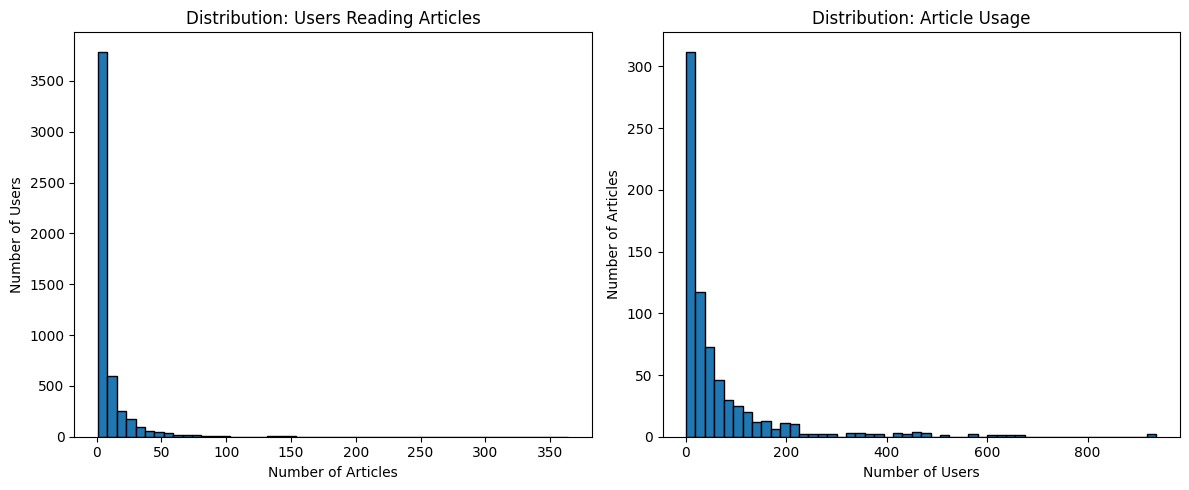

In [8]:
# Plot number of articles read by each user
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(user_interactions, bins=50, edgecolor='black')
plt.xlabel('Number of Articles')
plt.ylabel('Number of Users')
plt.title('Distribution: Users Reading Articles')
plt.tight_layout()

# Plot number of times each article was read
article_interactions = df.groupby('article_id')['email'].count()
plt.subplot(1, 2, 2)
plt.hist(article_interactions, bins=50, edgecolor='black')
plt.xlabel('Number of Users')
plt.ylabel('Number of Articles')
plt.title('Distribution: Article Usage')
plt.tight_layout()
plt.show()

In [9]:
# Calculate key metrics
median_val = int(user_interactions.median())
max_views_by_user = int(user_interactions.max())

print(f"\nMedian interactions per user: {median_val}")
print(f"Maximum interactions by any user: {max_views_by_user}")


Median interactions per user: 3
Maximum interactions by any user: 364


## 3. Calculate Unique Values

In [10]:
unique_articles = df['article_id'].nunique()
total_articles = df['article_id'].nunique()  # Same as unique_articles in this dataset
unique_users = df['email'].nunique()
user_article_interactions = len(df)

print(f"3. Dataset Statistics:")
print(f"Unique articles with interactions: {unique_articles}")
print(f"Total unique articles: {total_articles}")
print(f"Unique users: {unique_users}")
print(f"Total user-article interactions: {user_article_interactions}")

3. Dataset Statistics:
Unique articles with interactions: 714
Total unique articles: 714
Unique users: 5149
Total user-article interactions: 45993


## 4. Most Viewed Article

In [11]:
most_viewed = df.groupby('article_id')['email'].count().sort_values(ascending=False)
most_viewed_article_id = str(float(most_viewed.index[0]))
max_views = int(most_viewed.iloc[0])

print(f"4. Most Viewed Article:")
print(f"Article ID: {most_viewed_article_id}")
print(f"Views: {max_views}")

4. Most Viewed Article:
Article ID: 1429.0
Views: 937


## 5. Create User ID Mapping

In [12]:
def email_mapper(df=df):
    """Map email addresses to user IDs"""
    coded_dict = {
        email: num 
        for num, email in enumerate(df['email'].unique(), start=1)
    }
    return [coded_dict[val] for val in df['email']]

df['user_id'] = email_mapper(df)
del df['email']
print("User ID mapping created!")
print(df.head())

User ID mapping created!
   Unnamed: 0  article_id                                              title  \
0           0        1430  using pixiedust for fast, flexible, and easier...   
1           1        1314       healthcare python streaming application demo   
2           2        1429         use deep learning for image classification   
3           3        1338          ml optimization using cognitive assistant   
4           4        1276          deploy your python model as a restful api   

   user_id  
0        1  
1        2  
2        3  
3        4  
4        5  


## Test Solution Dictionary

In [13]:
sol_1_dict = {
    '`50% of individuals have _____ or fewer interactions.`': median_val,
    '`The total number of user-article interactions in the dataset is ______.`': user_article_interactions,
    '`The maximum number of user-article interactions by any 1 user is ______.`': max_views_by_user,
    '`The most viewed article in the dataset was viewed _____ times.`': max_views,
    '`The article_id of the most viewed article is ______.`': most_viewed_article_id,
    '`The number of unique articles that have at least 1 rating ______.`': unique_articles,
    '`The number of unique users in the dataset is ______`': unique_users,
    '`The number of unique articles on the IBM platform`': total_articles
}

print("✓ Part I Complete!")

✓ Part I Complete!


---
# PART II: RANK BASED RECOMMENDATIONS
---

## Function: Get Top Articles

In [15]:
def get_top_articles(n, df=df):
    """
    Get top n articles by number of interactions
    
    INPUT:
    n - (int) number of top articles to return
    df - (pandas dataframe) article interaction data
    
    OUTPUT:
    top_articles - (list) list of top n article titles
    """
    article_counts = df.groupby(['article_id', 'title']).size().reset_index(name='count')
    article_counts = article_counts.sort_values('count', ascending=False)
    top_articles = article_counts.head(n)['title'].tolist()
    return top_articles

## Function: Get Top Article IDs

In [16]:
def get_top_article_ids(n, df=df):
    """
    Get top n article IDs by number of interactions
    
    INPUT:
    n - (int) number of top articles to return
    df - (pandas dataframe) article interaction data
    
    OUTPUT:
    top_articles - (list) list of top n article IDs
    """
    article_counts = df.groupby('article_id').size().reset_index(name='count')
    article_counts = article_counts.sort_values('count', ascending=False)
    top_articles = article_counts.head(n)['article_id'].tolist()
    return top_articles

## Test Rank-Based Functions

In [17]:
print("Top 10 Article Titles:")
print(get_top_articles(10))
print("\nTop 10 Article IDs:")
print(get_top_article_ids(10))

print("\n✓ Part II Complete!")

Top 10 Article Titles:
['use deep learning for image classification', 'insights from new york car accident reports', 'visualize car data with brunel', 'use xgboost, scikit-learn & ibm watson machine learning apis', 'predicting churn with the spss random tree algorithm', 'healthcare python streaming application demo', 'finding optimal locations of new store using decision optimization', 'apache spark lab, part 1: basic concepts', 'analyze energy consumption in buildings', 'gosales transactions for logistic regression model']

Top 10 Article IDs:
[1429, 1330, 1431, 1427, 1364, 1314, 1293, 1170, 1162, 1304]

✓ Part II Complete!


---
# PART III: USER-USER BASED COLLABORATIVE FILTERING
---

## Create User-Item Matrix

In [18]:
def create_user_item_matrix(df, fill_value=0):
    """
    Create user-item interaction matrix
    
    INPUT:
    df - (pandas dataframe) with article_id, title, user_id columns
    fill_value - (int) value to fill for no interaction
    
    OUTPUT:
    user_item - (pandas dataframe) user-item matrix with 1s and 0s
    """
    # Create a dataframe with user-article interactions
    user_item = df.groupby(['user_id', 'article_id'])['title'].count().unstack(fill_value=fill_value)
    # Convert counts to binary (1 if interacted, 0 otherwise)
    user_item = (user_item > 0).astype(int)
    return user_item

user_item = create_user_item_matrix(df)
print(f"User-Item Matrix Shape: {user_item.shape}")
print(f"Users: {user_item.shape[0]}, Articles: {user_item.shape[1]}")

User-Item Matrix Shape: (5149, 714)
Users: 5149, Articles: 714


## Verify Matrix

In [19]:
assert user_item.shape[0] == 5149, "Error: Number of users doesn't match expected value"
assert user_item.shape[1] == 714, "Error: Number of articles doesn't match expected value"
assert user_item.sum(axis=1)[1] == 36, "Error: User 1 interaction count doesn't match"
print("✓ User-Item Matrix validated successfully!")

✓ User-Item Matrix validated successfully!


## Function: Find Similar Users

In [20]:
def find_similar_users(user_id, user_item=user_item, include_similarity=False):
    """
    Find users similar to a given user based on article interactions
    
    INPUT:
    user_id - (int) a user ID
    user_item - (pandas dataframe) user-item matrix
    include_similarity - (bool) whether to include similarity scores
    
    OUTPUT:
    similar_users - (list) ordered list of similar user IDs
    """
    # Get the user's row from the matrix
    user_vector = user_item.loc[user_id].values.reshape(1, -1)
    
    # Compute cosine similarity with all users
    similarities = cosine_similarity(user_vector, user_item.values)[0]
    
    # Create dataframe with user IDs and similarities
    sim_df = pd.DataFrame({
        'user_id': user_item.index,
        'similarity': similarities
    })
    
    # Remove the input user and sort by similarity
    sim_df = sim_df[sim_df['user_id'] != user_id].sort_values('similarity', ascending=False)
    
    if include_similarity:
        return sim_df[['user_id', 'similarity']].values.tolist()
    
    return sim_df['user_id'].tolist()

## Test Similar Users Function

In [22]:
print("10 most similar users to user 1:", find_similar_users(1)[:10])
print("5 most similar users to user 3933:", find_similar_users(3933)[:5])
print("3 most similar users to user 46:", find_similar_users(46)[:3])

10 most similar users to user 1: [3933, 46, 4201, 5034, 824, 253, 5041, 2305, 136, 395]
5 most similar users to user 3933: [1, 4201, 46, 253, 5034]
3 most similar users to user 46: [4201, 790, 5077]


## Function: Get Article Names

In [24]:
def get_article_names(article_ids, df=df):
    """
    Get article names from article IDs
    
    INPUT:
    article_ids - (list) list of article IDs
    df - (pandas dataframe) article data
    
    OUTPUT:
    article_names - (list) list of article names
    """
    article_names = df[df['article_id'].isin(article_ids)][['article_id', 'title']].drop_duplicates()
    article_names = article_names.set_index('article_id').loc[article_ids]['title'].tolist()
    return article_names

## Function: Get Ranked Article Unique Counts

In [25]:
def get_ranked_article_unique_counts(article_ids, user_item=user_item):
    """
    Get articles ranked by number of unique users who interacted with them
    
    INPUT:
    article_ids - (list) list of article IDs
    user_item - (pandas dataframe) user-item matrix
    
    OUTPUT:
    ranked_article_unique_counts - (list) tuples of (article_id, count)
    """
    # Get counts for specified articles
    article_counts = []
    for article_id in article_ids:
        if article_id in user_item.columns:
            count = user_item[article_id].sum()
            article_counts.append([article_id, count])
    
    # Sort by count descending
    article_counts.sort(key=lambda x: x[1], reverse=True)
    return article_counts

## Function: Get User Articles

In [28]:
def get_user_articles(user_id, user_item=user_item):
    """
    Get articles that a user has interacted with
    
    INPUT:
    user_id - (int) a user ID
    user_item - (pandas dataframe) user-item matrix
    
    OUTPUT:
    article_ids - (list) list of article IDs the user has seen
    article_names - (list) list of article titles
    """
    # Get articles where user has interaction (value = 1)
    user_articles = user_item.loc[user_id]
    article_ids = user_articles[user_articles == 1].index.tolist()
    article_names = get_article_names(article_ids)
    return article_ids, article_names

## Function: User-User Recommendations

In [29]:
def user_user_recs(user_id, m=10):
    """
    Make recommendations using user-user collaborative filtering
    
    INPUT:
    user_id - (int) a user ID
    m - (int) number of recommendations
    
    OUTPUT:
    recs - (list) list of recommended article IDs
    """
    # Get articles the user has already seen
    seen_articles, _ = get_user_articles(user_id)
    seen_articles = set(seen_articles)
    
    # Get similar users
    similar_users = find_similar_users(user_id)
    
    # Collect recommendations from similar users
    recs = []
    for similar_user in similar_users:
        if len(recs) >= m:
            break
        
        # Get articles this similar user has seen
        user_articles, _ = get_user_articles(similar_user)
        
        # Add articles the target user hasn't seen
        for article in user_articles:
            if article not in seen_articles and article not in recs:
                recs.append(article)
                if len(recs) >= m:
                    break
    
    return recs

## Test Recommendations

In [30]:
print("10 recommendations for user 1:")
print(get_article_names(user_user_recs(1, 10)))

10 recommendations for user 1:
['this week in data science (april 18, 2017)', 'this week in data science (may 2, 2017)', 'top 20 r machine learning and data science packages', 'improving the roi of big data and analytics through leveraging new sources of data', 'using apply, sapply, lapply in r', 'awesome deep learning papers', 'leverage python, scikit, and text classification for behavioral profiling', 'challenges in deep learning', 'do i need to learn r?', 'how can data scientists collaborate to build better business']


## Function: Get Top Sorted Users

In [36]:
def get_top_sorted_users(user_id, user_item=user_item):
    """
    Get similar users sorted by similarity and number of interactions
    
    INPUT:
    user_id - (int) a user ID
    user_item - (pandas dataframe) user-item matrix
    
    OUTPUT:
    neighbors_df - (pandas dataframe) with neighbor_id, similarity, num_interactions
    """
    # Get similar users with similarity scores
    similar_users_data = find_similar_users(user_id, include_similarity=True)
    
    # Create dataframe
    neighbors_df = pd.DataFrame(similar_users_data, columns=['neighbor_id', 'similarity'])
    neighbors_df['neighbor_id'] = neighbors_df['neighbor_id'].astype(int)
    
    # Add number of interactions for each neighbor
    neighbors_df['num_interactions'] = neighbors_df['neighbor_id'].apply(
        lambda x: user_item.loc[x].sum()
    )
    
    # Sort by similarity (descending) then by num_interactions (descending)
    neighbors_df = neighbors_df.sort_values(
        ['similarity', 'num_interactions'], 
        ascending=[False, False]
    )
    
    return neighbors_df

## Function: Improved User-User Recommendations

In [37]:
def user_user_recs_part2(user_id, m=10):
    """
    Improved user-user recommendations with better ranking
    
    INPUT:
    user_id - (int) a user ID
    m - (int) number of recommendations
    
    OUTPUT:
    recs - (list) list of recommended article IDs
    rec_names - (list) list of recommended article titles
    """
    # Get articles the user has already seen
    seen_articles, _ = get_user_articles(user_id)
    seen_articles = set(seen_articles)
    
    # Get similar users sorted by similarity and interactions
    neighbors_df = get_top_sorted_users(user_id)
    
    # Collect articles from similar users
    candidate_articles = []
    for _, neighbor in neighbors_df.iterrows():
        neighbor_id = int(neighbor['neighbor_id'])
        neighbor_articles, _ = get_user_articles(neighbor_id)
        
        # Add unseen articles
        for article in neighbor_articles:
            if article not in seen_articles and article not in candidate_articles:
                candidate_articles.append(article)
    
    # Rank candidates by popularity (number of unique users)
    if candidate_articles:
        article_popularity = get_ranked_article_unique_counts(candidate_articles)
        recs = [article[0] for article in article_popularity[:m]]
    else:
        # Fallback to top articles
        recs = get_top_article_ids(m)
    
    return recs, get_article_names(recs)

## Test Improved Recommendations

In [38]:
rec_ids, rec_names = user_user_recs_part2(20, 10)
print("Top 10 recommendations for user 20:")
print("IDs:", rec_ids)
print("Names:", rec_names)

Top 10 recommendations for user 20:
IDs: [1330, 1429, 1364, 1314, 1398, 1431, 1271, 1427, 1160, 43]
Names: ['insights from new york car accident reports', 'use deep learning for image classification', 'predicting churn with the spss random tree algorithm', 'healthcare python streaming application demo', 'total population by country', 'visualize car data with brunel', 'customer demographics and sales', 'use xgboost, scikit-learn & ibm watson machine learning apis', 'analyze accident reports on amazon emr spark', 'deep learning with tensorflow course by big data university']


## Test Similarity Values

In [39]:
user1_most_sim = int(get_top_sorted_users(1).iloc[0]['neighbor_id'])
user2_6th_sim = int(get_top_sorted_users(2).iloc[5]['neighbor_id'])
user131_10th_sim = int(get_top_sorted_users(131).iloc[9]['neighbor_id'])

sol_5_dict = {
    'The user that is most similar to user 1.': user1_most_sim,
    'The user that is the 6th most similar to user 2.': user2_6th_sim,
    'The user that is the 10th most similar to user 131.': user131_10th_sim,
}

print(f"User 1 most similar: {user1_most_sim}")
print(f"User 2 6th similar: {user2_6th_sim}")
print(f"User 131 10th similar: {user131_10th_sim}")

User 1 most similar: 3933
User 2 6th similar: 3586
User 131 10th similar: 383


In [54]:
print(get_top_sorted_users(1, user_item=user_item).head(n=1))
print(get_top_sorted_users(2, user_item=user_item).head(n=10))
print(get_top_sorted_users(131, user_item=user_item).head(n=10))

   neighbor_id  similarity  num_interactions
0         3933    0.986013                35
    neighbor_id  similarity  num_interactions
0          5083    0.730297                 5
1          1552    0.577350                 2
2          1890    0.577350                 2
3          1372    0.471405                 3
4          2941    0.433013                 8
23         3586    0.408248                 4
5          2595    0.408248                 1
6           331    0.408248                 1
7          2597    0.408248                 1
8           701    0.408248                 1
   neighbor_id  similarity  num_interactions
0         3870    0.986667                75
1          203    0.388909                96
2         4459    0.388909                96
3         3782    0.387585               135
4         4932    0.384308                52
5           40    0.384308                52
6           23    0.377647               135
7          242    0.375823                59

## Recommendations for New Users

In [40]:
new_user_recs = get_top_article_ids(10)
print("Recommendations for new user (top 10 popular articles):")
print(new_user_recs)

print("\n✓ Part III Complete!")

Recommendations for new user (top 10 popular articles):
[1429, 1330, 1431, 1427, 1364, 1314, 1293, 1170, 1162, 1304]

✓ Part III Complete!


---
# PART IV: CONTENT BASED RECOMMENDATIONS
---

## Prepare Data for Content Analysis

In [41]:
# Get unique articles for clustering
df_unique_articles = df[['article_id', 'title']].drop_duplicates().reset_index(drop=True)
print(f"Unique articles for content analysis: {len(df_unique_articles)}")

Unique articles for content analysis: 714


## Create TF-IDF Vectors

In [42]:
# Create TF-IDF vectors from article titles
max_features = 200
max_df = 0.75
min_df = 5

vectorizer = TfidfVectorizer(
    max_df=max_df,
    min_df=min_df,
    stop_words="english",
    max_features=max_features,
)

print("Running TF-IDF vectorization...")
X_tfidf = vectorizer.fit_transform(df_unique_articles['title'])
print(f"TF-IDF shape: {X_tfidf.shape[0]} samples, {X_tfidf.shape[1]} features")

Running TF-IDF vectorization...
TF-IDF shape: 714 samples, 125 features


## Apply LSA (Latent Semantic Analysis)

In [43]:
# Apply LSA for dimensionality reduction
lsa = make_pipeline(TruncatedSVD(n_components=50), Normalizer(copy=False))
X_lsa = lsa.fit_transform(X_tfidf)
explained_variance = lsa[0].explained_variance_ratio_.sum()
print(f"Explained variance of SVD: {explained_variance * 100:.1f}%")

Explained variance of SVD: 76.0%


## Find Optimal Number of Clusters

Finding optimal number of clusters...


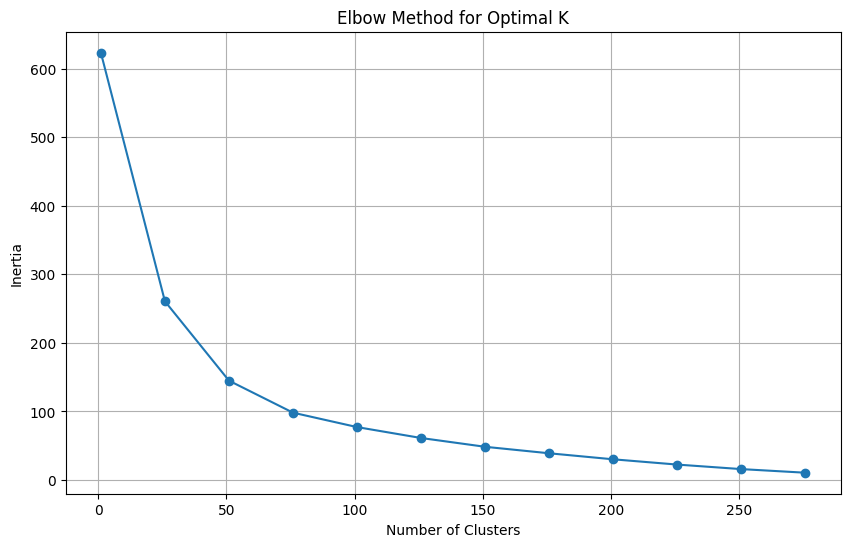

In [44]:
print("Finding optimal number of clusters...")
inertia = []
clusters = 300
step = 25
max_iter = 50
n_init = 5
random_state = 42

for k in range(1, clusters, step):
    kmeans = KMeans(
        n_clusters=k,
        max_iter=max_iter,
        n_init=n_init,
        random_state=random_state,
    ).fit(X_lsa)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, clusters, step), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

## Perform K-Means Clustering

In [45]:
# Use 50 clusters based on elbow analysis
n_clusters = 50
print(f"Using {n_clusters} clusters for article grouping...")

kmeans = KMeans(
    n_clusters=n_clusters,
    max_iter=max_iter,
    n_init=n_init,
    random_state=random_state
).fit(X_lsa)

# Map article IDs to cluster labels
article_cluster_map = dict(zip(
    df_unique_articles['article_id'], 
    kmeans.labels_
))

# Add cluster labels to main dataframe
df['title_cluster'] = df['article_id'].map(article_cluster_map)

# Display cluster distribution
cluster_counts = np.array(np.unique(kmeans.labels_, return_counts=True)).T
print("\nCluster distribution (first 10 clusters):")
print(cluster_counts[:10])

Using 50 clusters for article grouping...

Cluster distribution (first 10 clusters):
[[ 0 19]
 [ 1  3]
 [ 2 71]
 [ 3  9]
 [ 4 31]
 [ 5 38]
 [ 6  9]
 [ 7 17]
 [ 8 13]
 [ 9 18]]


## Function: Get Similar Articles

In [46]:
def get_similar_articles(article_id, df=df):
    """
    Get articles in the same content cluster
    
    INPUT:
    article_id - (int) an article ID
    df - (pandas dataframe) article data with cluster labels
    
    OUTPUT:
    articles_in_cluster - (list) article IDs in same cluster
    """
    # Get the cluster of the input article
    title_cluster = df[df['article_id'] == article_id]['title_cluster'].iloc[0]
    
    # Get all articles in this cluster
    articles_in_cluster = df[df['title_cluster'] == title_cluster]['article_id'].unique().tolist()
    
    # Remove the input article
    if article_id in articles_in_cluster:
        articles_in_cluster.remove(article_id)
    
    return articles_in_cluster

## Function: Make Content Recommendations

In [47]:
def make_content_recs(article_id, n, df=df):
    """
    Make content-based recommendations using article clusters
    
    INPUT:
    article_id - (int) an article ID
    n - (int) number of recommendations
    df - (pandas dataframe) article data
    
    OUTPUT:
    n_ranked_similar_articles - (list) recommended article IDs
    n_ranked_article_names - (list) recommended article titles
    """
    # Get similar articles in same cluster
    similar_articles = get_similar_articles(article_id, df)
    
    # Rank by popularity
    if similar_articles:
        ranked_articles = get_ranked_article_unique_counts(similar_articles)
        n_ranked_similar_articles = [art[0] for art in ranked_articles[:n]]
    else:
        # Fallback to top articles if no similar articles
        n_ranked_similar_articles = get_top_article_ids(n)
    
    n_ranked_article_names = get_article_names(n_ranked_similar_articles)
    
    return n_ranked_similar_articles, n_ranked_article_names

## Test Content Recommendations

In [48]:
rec_article_ids, rec_article_titles = make_content_recs(25, 10)
print("Content-based recommendations for article 25:")
print("IDs:", rec_article_ids)
print("Titles:", rec_article_titles)

print("\n✓ Part IV Complete!")

Content-based recommendations for article 25:
IDs: [1025, 101, 975, 766, 508, 547, 132, 878, 92, 693]
Titles: ['data tidying in data science experience', 'how to choose a project to practice data science', 'the data science process', 'making data science a team sport', 'data science in the cloud', 'trust in data science', 'collecting data science cheat sheets', '10 data science podcasts you need to be listening to right now', '9 mistakes to avoid when starting your career in data science', 'better together: spss and data science experience']

✓ Part IV Complete!


---
# PART V: MATRIX FACTORIZATION
---

## Perform SVD on User-Item Matrix

In [49]:
print("Performing SVD on user-item matrix...")
svd = TruncatedSVD(n_components=len(user_item.columns), n_iter=5, random_state=42)

u = svd.fit_transform(user_item)
v = svd.components_
s = svd.singular_values_

print(f"U shape: {u.shape}")
print(f"S shape: {s.shape}")
print(f"V^T shape: {v.shape}")

Performing SVD on user-item matrix...
U shape: (5149, 714)
S shape: (714,)
V^T shape: (714, 714)


## Evaluate Different Numbers of Latent Features

In [50]:
print("Evaluating prediction accuracy with different latent features...")
num_latent_feats = np.arange(10, 700+10, 20)
metric_scores = []

for k in num_latent_feats:
    # Reconstruct with k latent features
    u_new, vt_new = u[:, :k], v[:k, :]
    
    # Predict user-item matrix
    user_item_est = abs(np.around(np.dot(u_new, vt_new))).astype(int)
    user_item_est = np.clip(user_item_est, 0, 1)
    
    # Calculate metrics
    acc = accuracy_score(user_item.values.flatten(), user_item_est.flatten())
    precision = precision_score(user_item.values.flatten(), user_item_est.flatten())
    recall = recall_score(user_item.values.flatten(), user_item_est.flatten())
    metric_scores.append([acc, precision, recall])

Evaluating prediction accuracy with different latent features...


## Plot Metrics

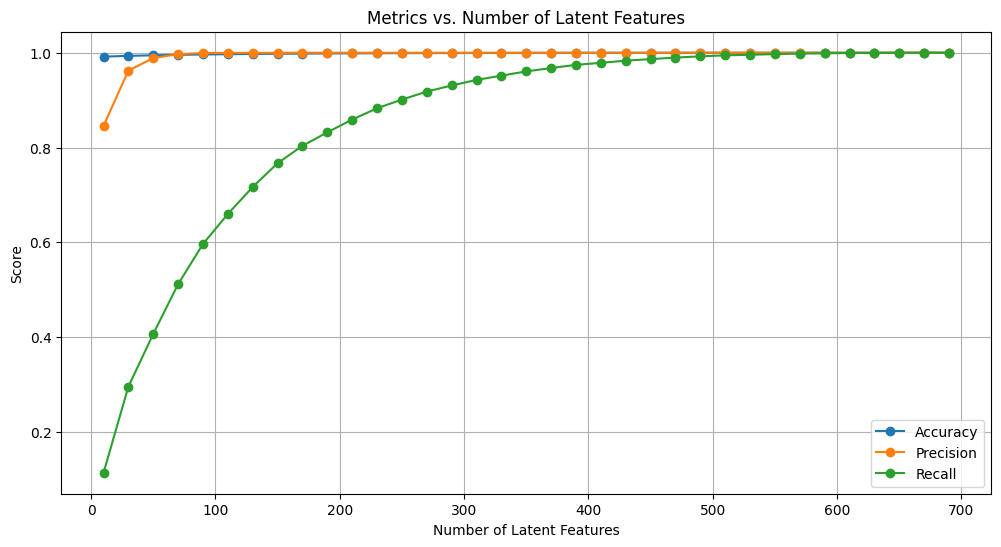

In [51]:
plt.figure(figsize=(12, 6))
plt.plot(num_latent_feats, metric_scores, marker='o')
plt.legend(['Accuracy', 'Precision', 'Recall'])
plt.xlabel('Number of Latent Features')
plt.ylabel('Score')
plt.title('Metrics vs. Number of Latent Features')
plt.grid(True)
plt.show()

## Function: Get SVD Similar Article IDs

In [52]:
def get_svd_similar_article_ids(article_id, vt, user_item=user_item, include_similarity=False):
    """
    Find similar articles using SVD matrix factorization
    
    INPUT:
    article_id - (int) an article ID
    vt - (numpy array) V^T matrix from SVD
    user_item - (pandas dataframe) user-item matrix
    include_similarity - (bool) whether to include similarity scores
    
    OUTPUT:
    article_ids - (list) similar article IDs
    """
    # Find the index of the article
    article_idx = user_item.columns.get_loc(article_id)
    
    # Compute cosine similarity (transpose vt to get articles x features)
    cos_sim = cosine_similarity(vt.T)
    
    # Get similarities for this article
    similarities = cos_sim[article_idx]
    
    # Create dataframe and sort
    sim_df = pd.DataFrame({
        'article_id': user_item.columns,
        'similarity': similarities
    })
    
    # Remove the input article and sort
    sim_df = sim_df[sim_df['article_id'] != article_id].sort_values('similarity', ascending=False)
    
    if include_similarity:
        return sim_df[['article_id', 'similarity']].values.tolist()
    
    return sim_df['article_id'].tolist()

## Test SVD Recommendations

In [53]:
# Test SVD recommendations with 200 latent features
k = 200
vt_new = v[:k, :]

print(f"Using {k} latent features for recommendations")
print("Current article:", get_article_names([4])[0])

rec_articles = get_svd_similar_article_ids(4, vt_new)[:10]
print("\nTop 10 similar articles to article 4:")
print("IDs:", rec_articles)
print("Titles:", get_article_names(rec_articles))

print("\n✓ Part V Complete!")

Using 200 latent features for recommendations
Current article: analyze ny restaurant data using spark in dsx

Top 10 similar articles to article 4:
IDs: [1199, 1068, 486, 1202, 176, 1120, 244, 793, 58, 132]
Titles: ['country statistics: crude oil - exports', 'airbnb data for analytics: athens reviews', 'use spark r to load and analyze data', 'country statistics: crude oil - proved reserves', 'top analytics tools in 2016', 'airbnb data for analytics: paris calendar', 'notebooks: a power tool for data scientists', '10 powerful features on watson data platform, no coding necessary', 'advancements in the spark community', 'collecting data science cheat sheets']

✓ Part V Complete!


---
# FINAL SUMMARY
---

## Project Summary

This recommendation system implements multiple approaches:

### 1. RANK-BASED RECOMMENDATIONS
- Simple popularity-based recommendations
- Best for new users with no interaction history
- Fast and easy to implement

### 2. USER-USER COLLABORATIVE FILTERING
- Finds similar users based on interaction patterns
- Recommends articles liked by similar users
- Good for users with some interaction history
- Handles cold-start for items well

### 3. CONTENT-BASED RECOMMENDATIONS
- Uses article title similarity (TF-IDF + clustering)
- Recommends articles with similar content
- Works even with limited user data
- Helps with article discovery

### 4. MATRIX FACTORIZATION (SVD)
- Discovers latent features in user-item interactions
- Provides personalized recommendations
- Best for users with substantial history
- Struggles with cold-start problem

### RECOMMENDATIONS FOR DIFFERENT USER TYPES:
- **New users (no history)**: Use rank-based recommendations
- **Users with little history (1-5 interactions)**: Combine rank-based and content-based
- **Users with moderate history (6-20 interactions)**: Use user-user collaborative filtering
- **Users with extensive history (20+ interactions)**: Use SVD-based recommendations

### NEXT STEPS:
- Implement hybrid approach combining multiple methods
- Add A/B testing framework to measure recommendation quality
- Create API for real-time recommendations
- Add more content features (article text, categories, tags)
- Implement online learning for continuous improvement